## Power Energy (PE) prediction using artificial neural network

In [1]:
import pandas as pd
path=r'https://raw.githubusercontent.com/sindhura-nk/Datasets/refs/heads/main/PowerPlant.csv'
df=pd.read_csv(path)
df

,AT,V,AP,RH,PE
0,8.34,40.77,1010.84,90.01,480.48
1,23.64,58.49,1011.40,74.20,445.75
2,29.74,56.90,1007.15,41.91,438.76
3,19.07,49.69,1007.22,76.79,453.09
4,11.80,40.66,1017.13,97.20,464.43
...,...,...,...,...,...
9563,15.12,48.92,1011.80,72.93,462.59
9564,33.41,77.95,1010.30,59.72,432.90
9565,15.99,43.34,1014.20,78.66,465.96
9566,17.65,59.87,1018.58,94.65,450.93


## Perform basic data quality checks

In [2]:
df.shape

(9568, 5)

In [3]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 9568 entries, 0 to 9567
Data columns (total 5 columns):
 #   Column  Non-Null Count  Dtype  
---  ------  --------------  -----  
 0   AT      9568 non-null   float64
 1   V       9568 non-null   float64
 2   AP      9568 non-null   float64
 3   RH      9568 non-null   float64
 4   PE      9568 non-null   float64
dtypes: float64(5)
memory usage: 373.9 KB


In [4]:
df.duplicated().sum()

np.int64(41)

In [5]:
df.drop_duplicates(inplace=True)

In [6]:
df.duplicated().sum()

np.int64(0)

In [7]:
df.isnull().sum()

AT    0
V     0
AP    0
RH    0
PE    0
dtype: int64

## Separate X and Y features

In [8]:
df.columns

Index(['AT', 'V', 'AP', 'RH', 'PE'], dtype='str')

In [9]:
df.dtypes

AT    float64
V     float64
AP    float64
RH    float64
PE    float64
dtype: object

In [10]:
X = df.drop(columns='PE')
Y=df[['PE']]

In [11]:
X.head()

,AT,V,AP,RH
0,8.34,40.77,1010.84,90.01
1,23.64,58.49,1011.40,74.20
2,29.74,56.90,1007.15,41.91
3,19.07,49.69,1007.22,76.79
4,11.80,40.66,1017.13,97.20


In [12]:
Y.head()

,PE
0,480.48
1,445.75
2,438.76
3,453.09
4,464.43


## Feature Engineering : Data Preprocessing - Data Cleaning and Data Scaling

In [13]:
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.impute import SimpleImputer
pre = make_pipeline(
    SimpleImputer(strategy='mean'),
    StandardScaler()
).set_output(transform='pandas')

## Split the data into training and testing

In [14]:
from sklearn.model_selection import train_test_split
xtrain,xtest,ytrain,ytest = train_test_split(X,Y,train_size=0.75,random_state=42)
xtrain = pre.fit_transform(xtrain)
xtest = pre.transform(xtest)

In [15]:
xtrain

,AT,V,AP,RH
1845,-0.895454,-0.799581,0.961864,0.844760
8505,0.936216,0.953401,-1.272911,-0.564076
8152,-0.966888,-0.970315,0.729110,0.563540
5023,0.138314,0.433329,0.983790,0.488959
1744,-1.224319,-0.971102,-2.262958,1.596048
...,...,...,...,...
5742,-0.116421,-1.067878,-1.360615,1.308670
5197,1.476687,1.526976,-1.706373,0.325427
5396,0.011621,-0.249610,-0.755118,1.463307
860,0.946999,1.139085,-0.421167,-0.445020


In [16]:
ytrain

,PE
1845,469.02
8505,436.65
8152,469.18
5023,445.18
1744,472.41
...,...
5742,459.96
5197,430.00
5396,447.96
860,440.45


## Model Building

In [17]:
from keras.models import Sequential
from keras.layers import Input,Dense,BatchNormalization,Dropout
from keras.callbacks import EarlyStopping

## Forward Propogation

In [18]:
# Initialize the model
model= Sequential()

# add the input layer
model.add(Input(shape=(xtrain.shape[1],)))

# Add the hidden layer 1
model.add(Dense(units=64,activation='relu'))

# Add the hidden layer 2
model.add(Dense(units=32,activation='relu'))

model.add(Dense(units=16, activation='relu'))

# Add the output layer
model.add(Dense(units=ytrain.shape[1],activation='linear'))




## Backward Propogation

In [19]:
model.compile(optimizer='adam',loss='mse',metrics=['mae'])
es = EarlyStopping(monitor='val_loss',patience=10)

In [20]:
nn=model.fit(xtrain,ytrain,validation_split=0.2,epochs=200,callbacks=[es])

Epoch 1/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 3s 5ms/step - loss: 148310.1250 - mae: 369.2016 - val_loss: 19901.2773 - val_mae: 119.1304
Epoch 2/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 10415.7520 - mae: 84.1622 - val_loss: 5496.0845 - val_mae: 61.0993
Epoch 3/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 3552.7600 - mae: 48.3984 - val_loss: 2264.2815 - val_mae: 38.1456
Epoch 4/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 1637.3363 - mae: 32.0354 - val_loss: 1173.9335 - val_mae: 26.6005
Epoch 5/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 4ms/step - loss: 859.5059 - mae: 22.8539 - val_loss: 608.0883 - val_mae: 19.2905
Epoch 6/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step - loss: 460.1264 - mae: 16.5930 - val_loss: 329.3065 - val_mae: 14.1955
Epoch 7/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 253.9515 - mae: 12.2123 - val_loss: 194.8935 - val_mae: 10.6118
Epoch 8/200
179/179 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 152.6318 - mae: 9.3652 - val_loss: 120.4060 - val_

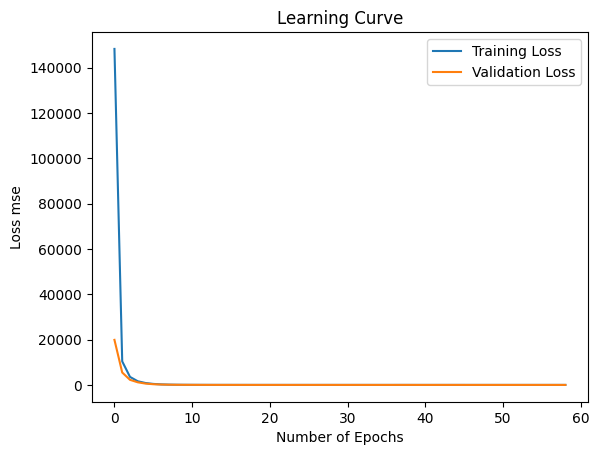

In [22]:
import matplotlib.pyplot as plt
plt.plot(nn.history['loss'],label='Training Loss')
plt.plot(nn.history['val_loss'],label='Validation Loss')
plt.title("Learning Curve")
plt.xlabel("Number of Epochs")
plt.ylabel("Loss mse")
plt.legend()
plt.show()

## Model Evaluation

In [23]:
model.evaluate(xtrain,ytrain)

224/224 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step - loss: 20.1534 - mae: 3.5321


[20.153358459472656, 3.5321357250213623]

In [24]:
model.evaluate(xtest,ytest)

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - loss: 20.2805 - mae: 3.5295


[20.28046989440918, 3.529482126235962]

## Model Evaluation — R2 Score

In [25]:
from sklearn.metrics import r2_score
ypred = model.predict(xtest)
print("R2 Score:", r2_score(ytest, ypred))

75/75 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step
R2 Score: 0.9320055246353149


## R2 score is 93% , so this model will perform well

In [26]:
# pip install joblib
import joblib

# save the pipeline - data cleaning and data preprocessing
joblib.dump(pre,'PowerPlant_model_pre.joblib')

# # save model
# model.save("PowerPlant_model.keras")
# Save weights separately (version-independent)
model.save_weights("PowerPlant_model_weights.weights.h5")

# Re-save preprocessor with current sklearn version
import joblib
joblib.dump(pre, "PowerPlant_model_pre.joblib")

['PowerPlant_model_pre.joblib']

In [27]:
from keras.models import load_model
m1 = load_model("PowerPlant_model.keras")
m1.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ dense (Dense)                   │ (None, 64)             │           320 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 16)             │           528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 1)              │            17 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 8,837 (34.52 KB)

 Trainable params: 2,945 (11.50 KB)

 Non-trainable params: 0 (0.00 B)

 Optimizer params: 5,892 (23.02 KB)